# Earth annulus convection in Underworld3

This notebook reproduces the configured 2-D Earth annulus convection run. The complete model implementation is defined in the notebook, with a 3480 km core–mantle boundary, a 6371 km surface, a 0–2800 K thermal gradient, smooth convergent surface velocities, and a three-layer viscosity profile.

The solver uses the normalized temperature `Theta = T / 2800` and viscosity relative to `10**21 Pa s` for numerical conditioning.

In [1]:
from dataclasses import dataclass
import numpy as np
import sympy
import underworld3 as uw
import matplotlib.pyplot as plt

In [2]:
@dataclass(frozen=True)
class EarthParameters:
    surface_radius_km: float = 6371.0
    cmb_radius_km: float = 3480.0
    temperature_surface_k: float = 0.0
    temperature_cmb_k: float = 2800.0
    velocity_scale_cm_per_yr: float = 4.0
    slow_velocity_cm_per_yr: float = 2.0
    fast_velocity_cm_per_yr: float = 6.0
    surface_viscosity_pa_s: float = 1.0e21
    asthenosphere_viscosity_pa_s: float = 1.0e19
    lower_mantle_viscosity_pa_s: float = 1.0e21
    asthenosphere_top_depth_km: float = 100.0
    asthenosphere_base_depth_km: float = 250.0
    lower_mantle_top_depth_km: float = 660.0
    thermal_diffusivity_m2_s: float = 1.0e-6
    density_kg_m3: float = 3300.0
    gravity_m_s2: float = 9.81
    thermal_expansion_k_inv: float = 3.0e-5

    @property
    def thickness_km(self):
        return self.surface_radius_km - self.cmb_radius_km

    @property
    def radius_inner(self):
        return self.cmb_radius_km / self.surface_radius_km

    @property
    def velocity_m_s(self):
        return self.velocity_scale_cm_per_yr * 1.0e-2 / (365.25 * 86400.0)

    @property
    def thickness_m(self):
        return self.thickness_km * 1000.0

    @property
    def kappa_nd(self):
        return self.thermal_diffusivity_m2_s / (self.thickness_m * self.velocity_m_s)

    @property
    def buoyancy_coeff_nd(self):
        delta_t = self.temperature_cmb_k - self.temperature_surface_k
        return (self.density_kg_m3 * self.gravity_m_s2 * self.thermal_expansion_k_inv * delta_t * self.thickness_m**2 / (self.surface_viscosity_pa_s * self.velocity_m_s))

    @property
    def rayleigh_number(self):
        delta_t = self.temperature_cmb_k - self.temperature_surface_k
        return (self.density_kg_m3 * self.gravity_m_s2 * self.thermal_expansion_k_inv * delta_t * self.thickness_m**3 / (self.surface_viscosity_pa_s * self.thermal_diffusivity_m2_s))


def make_viscosity_profile(mesh, params):
    x, y = mesh.X
    radius = sympy.sqrt(x**2 + y**2)
    r_surface = 1.0
    r_ast_top = r_surface - params.asthenosphere_top_depth_km / params.surface_radius_km
    r_ast_base = r_surface - params.asthenosphere_base_depth_km / params.surface_radius_km
    r_lower_top = r_surface - params.lower_mantle_top_depth_km / params.surface_radius_km
    eta_ref = params.surface_viscosity_pa_s
    eta_surface = params.surface_viscosity_pa_s / eta_ref
    eta_ast = params.asthenosphere_viscosity_pa_s / eta_ref
    eta_lower = params.lower_mantle_viscosity_pa_s / eta_ref
    profile = sympy.Piecewise((eta_ast, (radius >= r_ast_base) & (radius <= r_ast_top)), (eta_lower, radius <= r_lower_top), (eta_surface, True))
    metadata = {'r_asthenosphere_top': r_ast_top, 'r_asthenosphere_base': r_ast_base, 'r_lower_mantle_top': r_lower_top}
    return profile, metadata


def build_annulus_model(cell_size_km=250.0, steps=10, dt=None, return_state=False):
    if cell_size_km <= 0.0 or steps < 0:
        raise ValueError('cell_size_km must be positive and steps must be non-negative')
    uw.reset_default_model()
    uw.use_strict_units(False)
    uw.use_nondimensional_scaling(False)
    params = EarthParameters()
    mesh = uw.meshing.Annulus(radiusOuter=1.0, radiusInner=params.radius_inner, cellSize=cell_size_km / params.surface_radius_km, qdegree=3)
    velocity = uw.discretisation.MeshVariable('U', mesh, mesh.dim, vtype=uw.VarType.VECTOR, degree=2)
    pressure = uw.discretisation.MeshVariable('P', mesh, 1, vtype=uw.VarType.SCALAR, degree=1, continuous=True)
    temperature = uw.discretisation.MeshVariable('Theta', mesh, 1, degree=2)
    x, y = mesh.X
    radius = sympy.sqrt(x**2 + y**2)
    radial = sympy.Matrix([x / radius, y / radius])
    tangent = sympy.Matrix([-y / radius, x / radius])
    theta_linear = (1.0 - radius) / (1.0 - params.radius_inner)
    initial_theta = theta_linear + 0.02 * sympy.sin(2.0 * sympy.atan2(y, x)) * sympy.sin(sympy.pi * theta_linear)
    temperature.array[...] = uw.function.evaluate(initial_theta, temperature.coords).reshape(temperature.array.shape)
    initial_temperature_values = np.asarray(temperature.data[:, 0], dtype=float).copy()
    viscosity, viscosity_metadata = make_viscosity_profile(mesh, params)
    stokes = uw.systems.Stokes(mesh, velocityField=velocity, pressureField=pressure, verbose=False)
    stokes.constitutive_model = uw.constitutive_models.ViscousFlowModel
    stokes.constitutive_model.Parameters.shear_viscosity_0 = viscosity
    stokes.saddle_preconditioner = 1.0 / viscosity
    slow = params.slow_velocity_cm_per_yr / params.velocity_scale_cm_per_yr
    fast = params.fast_velocity_cm_per_yr / params.velocity_scale_cm_per_yr
    amplitude = sympy.Piecewise((slow, x >= 0.0), (fast, True))
    # sin(2 theta): divergence at theta=0, pi and convergence at pi/2, 3pi/2.
    v_theta = amplitude * 2.0 * x * y / radius**2
    surface_velocity = v_theta * tangent
    stokes.add_dirichlet_bc((surface_velocity[0], surface_velocity[1]), 'Upper')
    stokes.add_natural_bc(1.0e4 * radial.dot(velocity.sym) * radial, 'Lower')
    stokes.bodyforce = params.buoyancy_coeff_nd * temperature.sym[0] * radial
    adv_diff = uw.systems.AdvDiffusionSLCN(mesh, u_Field=temperature, V_fn=velocity.sym, monotone_mode='clamp')
    adv_diff.constitutive_model = uw.constitutive_models.DiffusionModel
    adv_diff.constitutive_model.Parameters.diffusivity = params.kappa_nd
    adv_diff.theta = 0.5
    adv_diff.add_dirichlet_bc(1.0, 'Lower')
    adv_diff.add_dirichlet_bc(0.0, 'Upper')
    timestep = dt if dt is not None else 0.25 * cell_size_km / params.surface_radius_km
    stokes.solve(zero_init_guess=True)
    initial_velocity_values = np.asarray(velocity.data, dtype=float).copy()
    for _ in range(steps):
        adv_diff.solve(timestep=timestep, zero_init_guess=True)
        stokes.solve(zero_init_guess=False)
    probe_radii = np.array([1.0 - 50.0 / params.surface_radius_km, 1.0 - 150.0 / params.surface_radius_km, 1.0 - 1000.0 / params.surface_radius_km])
    eta_probe = np.asarray(uw.function.evaluate(viscosity, np.column_stack((probe_radii, np.zeros(3))))).reshape(-1)
    temperature_values = np.asarray(temperature.data[:, 0], dtype=float)
    final_velocity_values = np.asarray(velocity.data, dtype=float).copy()
    diagnostics = {'temperature_min_nd': float(temperature_values.min()), 'temperature_max_nd': float(temperature_values.max()), 'eta_probe_nd': eta_probe.tolist(), 'rayleigh': params.rayleigh_number, 'kappa_nd': params.kappa_nd, 'buoyancy_coeff_nd': params.buoyancy_coeff_nd, 'dt_nd': timestep, 'steps': steps, 'mesh_vertices': int(temperature.coords.shape[0]), 'viscosity_metadata': viscosity_metadata}
    assert np.allclose(eta_probe, [1.0, 0.01, 1.0], rtol=0.0, atol=1.0e-12)
    assert np.isfinite(temperature_values).all() and temperature_values.min() > -0.05 and temperature_values.max() < 1.05
    if return_state:
        diagnostics['state'] = {'mesh': mesh, 'velocity': velocity, 'pressure': pressure, 'temperature': temperature, 'viscosity': viscosity, 'params': params, 'initial_temperature': initial_temperature_values, 'initial_velocity': initial_velocity_values, 'final_velocity': final_velocity_values}
    return diagnostics

params = EarthParameters()
print('Underworld3 Earth annulus convection')
print(f'  mantle thickness: {params.thickness_km:.0f} km')
print(f'  surface velocities: slow={params.slow_velocity_cm_per_yr:g}, fast={params.fast_velocity_cm_per_yr:g} cm/yr')
print(f'  temperature: {params.temperature_surface_k:g} -> {params.temperature_cmb_k:g} K')
print(f'  viscosity: {params.surface_viscosity_pa_s:.0e} / {params.asthenosphere_viscosity_pa_s:.0e} / {params.lower_mantle_viscosity_pa_s:.0e} Pa s')

Underworld3 Earth annulus convection
  mantle thickness: 2891 km
  surface velocities: slow=2, fast=6 cm/yr
  temperature: 0 -> 2800 K
  viscosity: 1e+21 / 1e+19 / 1e+21 Pa s


## Run the model

The notebook uses a 250 km target element size and runs for 10 thermal timesteps. Increase `steps` or reduce `cell_size_km` for a longer or more resolved experiment.

In [3]:
run = build_annulus_model(
    cell_size_km=250.0,
    steps=10,
    return_state=True,
)
state = run.pop('state')
for key in ('mesh_vertices', 'steps', 'dt_nd', 'rayleigh', 'kappa_nd', 'buoyancy_coeff_nd', 'eta_probe_nd', 'temperature_min_nd', 'temperature_max_nd'):
    print(f'{key}: {run[key]}')

mesh_vertices: 7186
steps: 10
dt_nd: 0.009810076911002982
rayleigh: 65706223.76162737
kappa_nd: 0.0002728951919750951
buoyancy_coeff_nd: 17930.91254738786
eta_probe_nd: [1.0, 0.01, 1.0]
temperature_min_nd: 0.0
temperature_max_nd: 1.0


In [4]:
# Regression checks for the requested physical setup.
assert np.allclose(run['eta_probe_nd'], [1.0, 0.01, 1.0])
assert params.temperature_surface_k == 0.0
assert params.temperature_cmb_k == 2800.0
assert 0.0 <= run['temperature_min_nd'] <= 1.0
assert 0.0 <= run['temperature_max_nd'] <= 1.0
print('All requested setup checks passed.')

All requested setup checks passed.


## Temperature and velocity field

The outer velocity is tangent to the surface and uses `v_theta = A(theta) sin(2 theta)`. The four equal angular sectors alternate between convergence and divergence: the divergence at `theta=0` is slow (2 cm/yr on both sides), while the divergence at `theta=pi` is fast (6 cm/yr on both sides). The two intervening sectors converge.

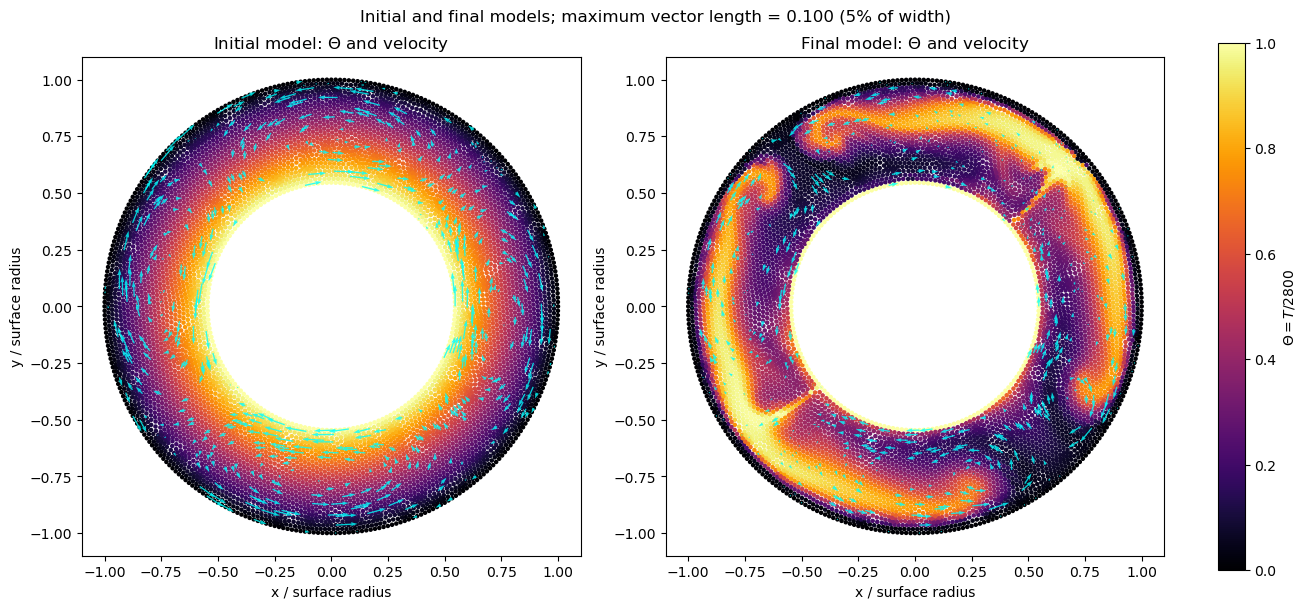

In [5]:
temperature = state['temperature']
coords = np.asarray(temperature.coords)
initial_theta_values = state['initial_temperature']
final_theta_values = np.asarray(temperature.data[:, 0])
initial_velocity_values = state['initial_velocity']
final_velocity_values = state['final_velocity']

# Scale plotted arrows so the longest vector is 0.05 of the total plot width.
plot_width = coords[:, 0].max() - coords[:, 0].min()
arrow_length = 0.05 * plot_width
stride = max(1, len(coords) // 500)

def scaled_vectors(vectors):
    speed = np.linalg.norm(vectors, axis=1)
    scale = arrow_length / speed.max() if speed.max() > 0 else 0.0
    return vectors * scale

fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
for ax, values, vectors, title in ((axes[0], initial_theta_values, initial_velocity_values, 'Initial model'), (axes[1], final_theta_values, final_velocity_values, 'Final model')):
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=values, s=5, cmap='inferno', vmin=0, vmax=1)
    arrows = scaled_vectors(vectors)
    ax.quiver(coords[::stride, 0], coords[::stride, 1], arrows[::stride, 0], arrows[::stride, 1], color='cyan', alpha=0.8, scale=1, scale_units='xy', angles='xy')
    ax.set_aspect('equal')
    ax.set_title(f'{title}: $\\Theta$ and velocity')
    ax.set_xlabel('x / surface radius')
    ax.set_ylabel('y / surface radius')
fig.colorbar(scatter, ax=axes, label='$\\Theta = T/2800$')
fig.suptitle(f'Initial and final models; maximum vector length = {arrow_length:.3f} ({arrow_length / plot_width:.0%} of width)')
plt.show()

## Radial viscosity profile

The asthenosphere is 100–250 km depth, while the lower mantle begins at 660 km depth. The unlabelled mantle interval uses the surface/reference viscosity.

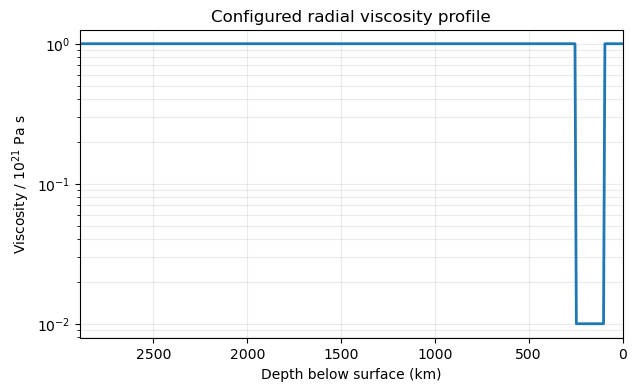

In [6]:
r = np.linspace(params.radius_inner, 1.0, 400)
sample_points = np.column_stack((r, np.zeros_like(r)))
eta = np.asarray(__import__('underworld3').function.evaluate(state['viscosity'], sample_points)).reshape(-1)
depth_km = (1.0 - r) * params.surface_radius_km

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_km, eta, linewidth=2)
ax.set_yscale('log')
ax.set_xlim(depth_km.max(), depth_km.min())
ax.set_xlabel('Depth below surface (km)')
ax.set_ylabel('Viscosity / $10^{21}$ Pa s')
ax.set_title('Configured radial viscosity profile')
ax.grid(True, which='both', alpha=0.25)
plt.show()

## Re-running

From the Underworld3 checkout, execute this notebook with:

```bash
pixi run -e runtime jupyter notebook ../annulus_2D/earth_annulus_convection.ipynb
```

The same calculation is also available as a command-line test:

```bash
pixi run -e runtime python ../annulus_2D/test_annulus_convection.py --steps 20
```